# BÀI TẬP LAB 03: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - AMES HOUSING DATASET

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Đọc tập dữ liệu train và test từ Kaggle

In [4]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')


# Kiểm tra kích thước dữ liệu (Shape)

In [5]:
print("=== 1. KÍCH THƯỚC DỮ LIỆU ===")
print(f"Kích thước tập Train (Số dòng, Số cột): {train_df.shape}")
print(f"Kích thước tập Test (Số dòng, Số cột):  {test_df.shape}")

=== 1. KÍCH THƯỚC DỮ LIỆU ===
Kích thước tập Train (Số dòng, Số cột): (1460, 81)
Kích thước tập Test (Số dòng, Số cột):  (1459, 80)


# Đọc thông tin tổng quan (Info & Describe)

In [6]:
print("\n=== 2. THÔNG TIN KIỂU DỮ LIỆU (INFO) ===")
print(train_df.info())

print("\n=== 3. THỐNG KÊ MÔ TẢ BIẾN SỐ (DESCRIBE) ===")
print(train_df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].head(10))


=== 2. THÔNG TIN KIỂU DỮ LIỆU (INFO) ===
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 n

# Phân loại 79 thuộc tính (Numerical vs Categorical)

In [7]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.drop(['Id', 'SalePrice'])
cat_cols = train_df.select_dtypes(include=['object']).columns

print("\n=== 4. PHÂN LOẠI ĐẶC TRƯNG (FEATURES) ===")
print(f"Số lượng biến định lượng (Numerical): {len(num_cols)}")
print(f"Số lượng biến định tính (Categorical): {len(cat_cols)}")



=== 4. PHÂN LOẠI ĐẶC TRƯNG (FEATURES) ===
Số lượng biến định lượng (Numerical): 36
Số lượng biến định tính (Categorical): 43


# Phân tích biến mục tiêu SalePrice (Kiểm tra Skewness & Log Transform)


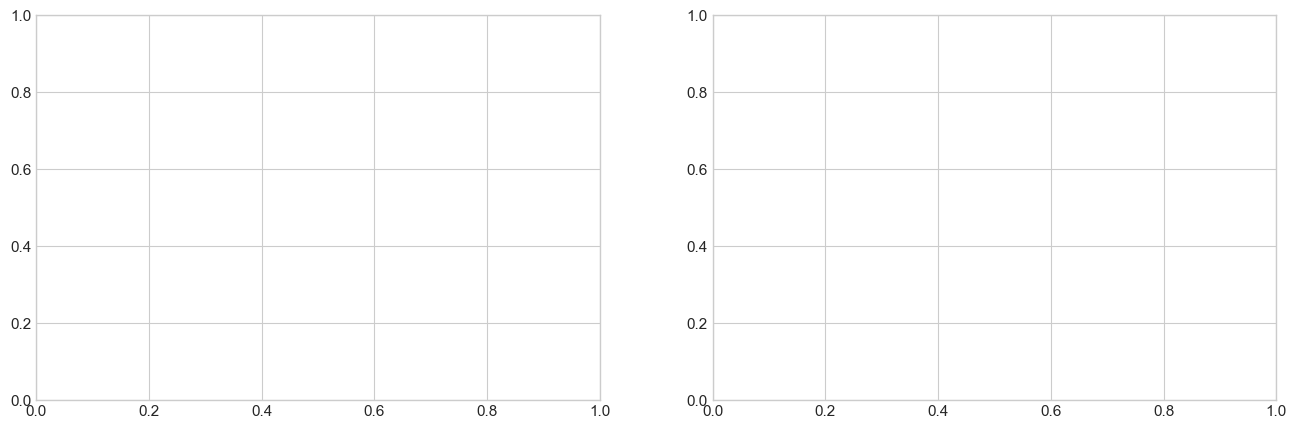

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

## Biểu đồ SalePrice gốc (Nhận xét: Bị lệch phải - Right Skewed)

In [9]:
sns.histplot(train_df['SalePrice'], kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title(f"Phân phối SalePrice Gốc (Skewness: {train_df['SalePrice'].skew():.2f})", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Giá bán SalePrice ($)")

Text(0.5, 4.444444444444448, 'Giá bán SalePrice ($)')

## Biến đổi Log1p đưa SalePrice về Phân phối chuẩn (Normal Distribution)

In [10]:
train_df['SalePrice_Log'] = np.log1p(train_df['SalePrice'])
sns.histplot(train_df['SalePrice_Log'], kde=True, ax=axes[1], color='#059669')
axes[1].set_title(f"Phân phối SalePrice Sau khi Log1p (Skewness: {train_df['SalePrice_Log'].skew():.2f})", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Log1p(SalePrice)")

plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

# Phân tích đơn biến cho một số đặc trưng quan trọng

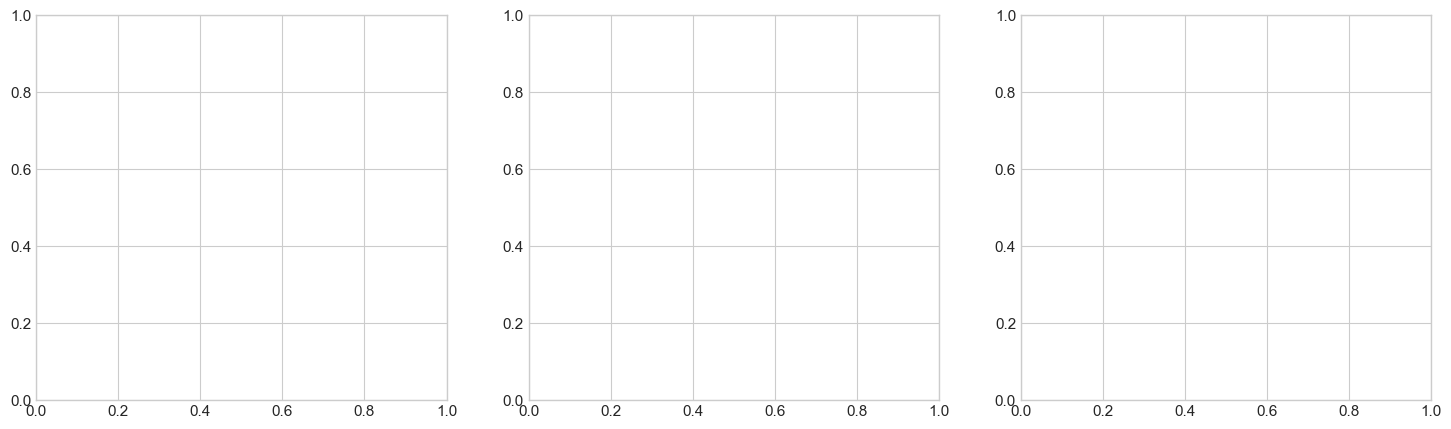

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

## Diện tích sinh hoạt (GrLivArea)

In [12]:
sns.histplot(train_df['GrLivArea'], kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title('Phân phối diện tích GrLivArea (sq ft)', fontweight='bold')


Text(0.5, 1.0, 'Phân phối diện tích GrLivArea (sq ft)')

## Chất lượng tổng thể (OverallQual)

In [13]:
sns.countplot(x='OverallQual', data=train_df, ax=axes[1], palette='Blues_r')
axes[1].set_title('Phân phối chất lượng OverallQual (1-10)', fontweight='bold')


Text(0.5, 1.0, 'Phân phối chất lượng OverallQual (1-10)')

## Top 10 Khu vực có nhiều giao dịch nhất (Neighborhood)

In [14]:
top_neighborhoods = train_df['Neighborhood'].value_counts().head(10)
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, ax=axes[2], palette='viridis')
axes[2].set_title('Top 10 Khu vực có nhiều giao dịch nhất', fontweight='bold')

plt.tight_layout()
plt.show()



<Figure size 1200x600 with 0 Axes>

# Kiểm tra và Thống kê Dữ liệu bị khuyết (Missing Values)


In [15]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_perc = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({'Số lượng khuyết': missing, 'Tỉ lệ (%)': missing_perc})

print("\n=== TOP 15 ĐẶC TRƯNG BỊ KHUYẾT DỮ LIỆU NHIỀU NHẤT ===")
print(missing_df.head(15))




=== TOP 15 ĐẶC TRƯNG BỊ KHUYẾT DỮ LIỆU NHIỀU NHẤT ===
              Số lượng khuyết  Tỉ lệ (%)
PoolQC                   1453  99.520548
MiscFeature              1406  96.301370
Alley                    1369  93.767123
Fence                    1179  80.753425
MasVnrType                872  59.726027
FireplaceQu               690  47.260274
LotFrontage               259  17.739726
GarageType                 81   5.547945
GarageYrBlt                81   5.547945
GarageFinish               81   5.547945
GarageQual                 81   5.547945
GarageCond                 81   5.547945
BsmtExposure               38   2.602740
BsmtFinType2               38   2.602740
BsmtQual                   37   2.534247


## Biểu đồ hiển thị dữ liệu thiếu

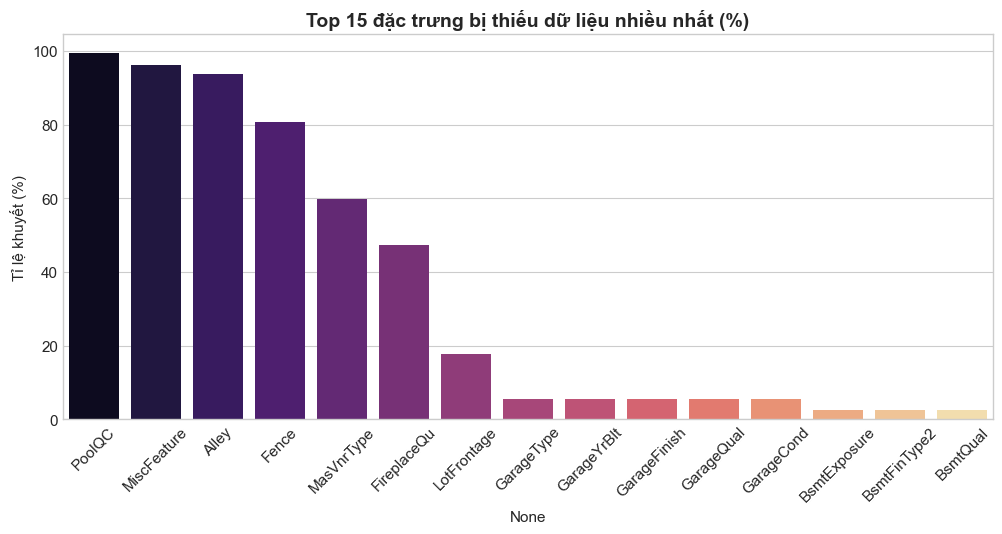

In [16]:
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_df.head(15).index, y=missing_df.head(15)['Tỉ lệ (%)'], palette='magma')
plt.xticks(rotation=45)
plt.title('Top 15 đặc trưng bị thiếu dữ liệu nhiều nhất (%)', fontsize=14, fontweight='bold')
plt.ylabel('Tỉ lệ khuyết (%)')
plt.show()